# 07-Reinforced Learning

# Reinforced Learning

Reinforcement Learning ist die einzige klassische Machine-Learning-Strategie, bei der zu Beginn keine Trainingsdaten vorhanden sind. Statt mit einem festen Datensatz zu arbeiten, sammelt das System seine Erfahrungen selbst – durch Interaktion mit einer Umgebung.

Ein Agent führt Aktionen aus und erhält dafür Rückmeldungen in Form von Belohnungen oder Bestrafungen. Durch dieses Feedback lernt der Agent schrittweise, sein Verhalten so anzupassen, dass langfristig möglichst hohe Belohnungen erzielt werden. Zum Lernen werden Markov-Prozesse verwendet.

# Begriffsdefinitionen 

**Agent**
Das lernende System
- Beobachtet den aktuellen Zustand $s_t$ im Zustandsraum $\mathcal{S}$
- Wählt eine Aktion $a_t$ ​im Aktionsraum $\mathcal{A}$
- Lernt aus dem erhaltenen Reward

**Environment (Umgebung)**
Alles außerhalb des Agenten

**Aktueller Zustand $s_t$**
Information, die der Agent über die Welt bekommt.

**Aktion $a_t$** 
Die Entscheidung des Agenten im Zustand $s_t$ über die Policy $\pi$
$$a_t = \pi \left( a_t | s_t \right), a_t \in \mathcal{A}$$

**Policy $\pi$**
Die Policy $\pi$ ist die Entscheidungsregel des Agenten.
$\pi \left( a | s \right)$ ist die Wahrscheinlichkeit, im Zustand $s$ die Aktion $a$ zu wählen.

**Reward $r_r$**
Der Reward ist das einzige Signal, das dem Agenten sagt, ob er gut oder schlecht gehandelt hat
$$r_t = R(s_t, a_t)$$
Der Agent erhält nach jeder Aktion ein skalare Rückmeldung $r_t$, die die Qualität seiner Entscheidung bewertet. Auf Basis dieser Rückmeldungen wird schrittweise eine Policy optimiert, sodass der erwartete Return 
$$G_t = \sum_{k=0}^{\infty} \gamma^k r_{t+k}$$
maximiert wird.

**Value-Funktion**
Die Value-Funktion ist ein Maß dafür, wie gut deine Zukunft von einem bestimmten Zustand aus sein kann. Für eine gegebene Policy $\pi$ ist die Value-Funktion

$$V^{\pi}(s) = \mathbb{E}\left[ G_t \mid s_t = s \right]$$

Dabei ist $\mathbb{E}$ ist der Erwartungswert, also der durchschnittliche Wert über alle möglichen Zufallsverläufe.
Zurückgegeben wird der Return $G_t$, welcher die gesamte diskontierte Zukunftsbelohnung ist
$$G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \dots$$
dabei ist $\gamma$ der Discount-Faktor mit $\gamma \in \left[0,1\right]$. $\gamma$ bestimmt, wie weit in die Zukunft der Agent denkt.


# Markov-Prozess

Ein Markov-Prozess ist ein stochastischer Prozess, bei dem die Wahrscheinlichkeit für zukünftige Zustände ausschließlich vom aktuellen Zustand abhängt, nicht von der Vergangenheit (Gedächtnislosigkeit). Er modelliert zufällige Systeme, wobei Übergänge zwischen Zuständen mit festen Wahrscheinlichkeiten erfolgen.

Der zentrale Punkt ist die Markov-Eigenschaft:

$$P(s_{t+1} \mid s_t, a_t, s_{t-1}, \dots) = P(s_{t+1} \mid s_t, a_t)$$

Die State-Value-Funktion $V^\pi \left( s \right)$ bewertet nur den Zustand. Die Action-Value-Funktion (Q-Funktion) $Q^\pi \left( s,a \right)$ bewertet wie gut ist es, in Zustand s Aktion a zu wählen?

Gesucht wird die optimale Value-Funktion $V^*(s) = \max_{\pi} V^{\pi}(s)$.

Dies wird beschrieben durch die **Bellman-Optimalitätsgleichung** $V^*(s) = \max_{a} \mathbb{E} \left[ r + \gamma V^*(s') \right]$

# Beispiel: Roboter im Labyrinth

Ein kleiner Roboter soll seinen Weg durch ein Labyrinth finden und dies mit RL lernen.

## Labyrinth-Design

Das Labyrinth wird als Numpy-Array designed.

. &rarr; frei
\# &rarr; Wand 
S &rarr; Start
G &rarr; Ziel

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Labyrinth 
# -----------------------------

# Labyrinth zeichen
maze_str = [
    "#####################",
    "#S....#.......#.....#",
    "###.###.#####.#.###.#",
    "#...#...#...#.#...#.#",
    "#.###.###.#.#.###.#.#",
    "#.#...#...#.#.....#.#",
    "#.#.###.###.#######.#",
    "#.#.#...#...#.....#.#",
    "#.#.#.###.###.###.#.#",
    "#...#.........#...#.#",
    "#####.###.#.###.###.#",
    "#.....#...#...#.....#",
    "#.#####.#############",
    "#..................G#",
    "#####################",
]
H = len(maze_str)
W = len(maze_str[0])

# Numpy array erstellen und der Zeichnung entsprechend füllen
maze = np.zeros((H, W), dtype=np.int32)
start = None
goal = None

for r in range(H):
    for c in range(W):
        ch = maze_str[r][c]
        if ch == "#":
            maze[r, c] = 1
        elif ch == "S":
            start = (r, c)
        elif ch == "G":
            goal = (r, c)

# prüfen, dass Start und Ziel nur einfach vorhanden sind.
assert start is not None and goal is not None

Das zweidimensionale `maze`-Array wird in ein RGB-Bild `(H, W, 3)` umgewandelt.  
Zunächst wird ein weißes Bild erzeugt:

```python
img = np.ones((H, W, 3), dtype=np.float32)
```

Wände (`maze == 1`) werden dunkel eingefärbt, der Start grün und das Ziel rot:

```python
img[maze == 1] = [0.1, 0.1, 0.1]
img[sr, sc] = [0.2, 0.9, 0.2]
img[gr, gc] = [0.95, 0.2, 0.2]
```

Mit `plt.imshow(img, interpolation="nearest")` wird das Bild ohne Glättung dargestellt.  
Achsen und `plt.grid(True)` machen die Grid-Struktur sichtbar.

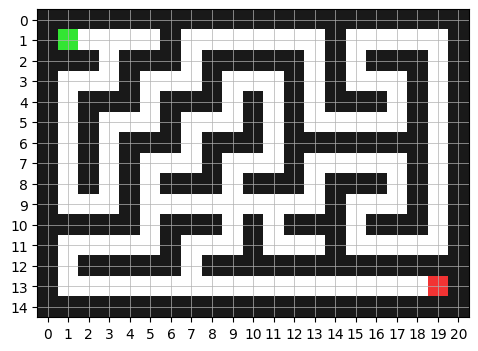

In [2]:
img = np.ones((H, W, 3), dtype=np.float32)

# Wände schwarz
img[maze == 1] = [0.1, 0.1, 0.1]

# Start grün, Ziel rot
sr, sc = start
gr, gc = goal
img[sr, sc] = [0.2, 0.9, 0.2]
img[gr, gc] = [0.95, 0.2, 0.2]

plt.figure(figsize=(6, 4))
plt.imshow(img, interpolation="nearest")
plt.xticks(range(W))
plt.yticks(range(H))
plt.grid(True, linewidth=0.5)

## Hilfsfunktionen

In [3]:
# Definition der möglichen Aktionen: hoch, rechts, runter, links
ACTIONS = np.array([
    (-1, 0),
    (0, 1),
    (1, 0),
    (0, -1),
], dtype=np.int32)

# Wandelt zweidimensioalen Index in einen eindimensionalen Index um
def state_to_idx(s):
    """(r,c) -> state index"""
    return s[0] * W + s[1]

# Wandelt eindimenstionale Index wieder in zweidimensionalen Index um
def idx_to_state(i):
    """state index -> (r,c)"""
    return (i // W, i % W)

# Prüft, ob eine Position innerhalb des Gitters liegt und keine Wand ist
def is_free(r, c):
    return 0 <= r < H and 0 <= c < W and maze[r, c] == 0

## Step-Funktion

Die Funktion `step(state, action)` beschreibt die Zustandsübergänge des Agenten im Labyrinth.

1. Ausgehend vom aktuellen Zustand `(r, c)` wird mithilfe des gewählten Aktionsvektors die neue Position `(nr, nc)` berechnet.
2. Standardmäßig erhält der Agent eine kleine negative Schrittstrafe (`-0.04`), um kürzere Wege zu fördern.
3. Falls die neue Position außerhalb des Gitters liegt oder eine Wand ist:
   - bleibt der Agent auf seiner alten Position,
   - erhält eine stärkere Strafe (`-0.2`).
4. Falls das Ziel erreicht wird:
   - erhält der Agent eine Belohnung (`+1.0`),
   - die Episode wird beendet (`done = True`).

Die Funktion gibt zurück:

- den neuen Zustand `(nr, nc)`,
- den erhaltenen Reward,
- ein `done`-Flag zur Kennzeichnung des Episodenendes.

In [4]:
# -----------------------------
# 2) Step-Funktion 
# -----------------------------
def step(state, action):
    r, c = state
    dr, dc = ACTIONS[action]
    nr, nc = r + dr, c + dc

    # Default step reward, damit eine Lösung gefunden wird, die möglichst wenige Schritte benötigt
    reward = -0.04
    done = False

    # Wand oder außerhalb -> bleib stehen + extra Strafe
    if not (0 <= nr < H and 0 <= nc < W) or maze[nr, nc] == 1:
        nr, nc = r, c
        reward = -0.2

    # Ziel, dann reward!
    if (nr, nc) == goal:
        reward = 1.0
        done = True

    return (nr, nc), reward, done

## Q-Learning und ε-greedy Exploration

Im Folgenden wird das Q-Learning-Verfahren mit einer **ε-greedy-Strategie** zur Exploration implementiert.

Zu Beginn des Trainings besitzt der Agent keine oder nur sehr geringe Kenntnisse über die Umgebung. In dieser Phase ist Exploration essenziell, da nur durch das Ausprobieren verschiedener Aktionen Informationen über die Struktur der Umgebung gesammelt werden können.

Im weiteren Verlauf gewinnt der Agent zunehmend Wissen über die erwarteten Belohnungen einzelner Zustands-Aktions-Paare. Nun wird Exploitation wichtiger: Der Agent nutzt sein bisher gelerntes Wissen, um möglichst hohe Belohnungen zu erzielen.

Da Exploration und Exploitation nicht gleichzeitig maximiert werden können, entsteht ein grundlegender Zielkonflikt, der als **Exploration–Exploitation Trade-off** bezeichnet wird:

- **Exploration** verbessert langfristig die Wissensbasis des Agenten.
- **Exploitation** maximiert kurzfristig die zu erwartende Belohnung.

Die ε-greedy-Strategie stellt eine einfache, aber wirkungsvolle Methode dar, diesen Zielkonflikt zu kontrollieren, indem Exploration anfangs dominiert und im Verlauf des Trainings schrittweise reduziert wird.

Die zugehörige Policy ist definiert als Wahrscheinlichkeit, im Zustand $s$ die Aktion $a$ zu wählen, unter einer ε-greedy Policy.

$$
\pi_{\varepsilon}(a \mid s)
=
\begin{cases}
1 - \varepsilon + \dfrac{\varepsilon}{|\mathcal{A}|}
& \text{falls $a$ die beste Aktion ist } a = \arg\max_{a'} Q(s,a') \\[8pt]
\dfrac{\varepsilon}{|\mathcal{A}|}
& \text{sonst}
\end{cases}
$$

Wenn $a$ die beste Aktion ist, wird mit Wahrscheinlichkeit $(1-\varepsilon)$ diese Aktion ausgewählt (Exploitation) und mit Wahrscheinlichkeit $\varepsilon$ eine zufällige Aktion (Exploration).
Ist $a$ nicht die beste Aktion, wird eine zufällige Aktion gewählt. 

Dies bedeutet im Code: Bei jedem Entscheidungsschritt wird eine Zufallszahl im Intervall $[0,1]$ erzeugt:

- Ist die Zufallszahl kleiner als $\varepsilon$, wird eine **zufällige Aktion** gewählt (Exploration).
- Andernfalls wird die aktuell beste bekannte Aktion gemäß der Q-Tabelle gewählt (Exploitation).

Der Parameter $\varepsilon$ bestimmt somit die Wahrscheinlichkeit für Exploration.

Nach jeder Episode wird $\varepsilon$ reduziert, um den Anteil zufälliger Entscheidungen im Verlauf des Trainings schrittweise zu verringern:

$$
\varepsilon_{\text{neu}} = \delta \cdot \varepsilon
$$

wobei $\delta \in (0,1)$ der sogenannte Decay-Faktor ist.


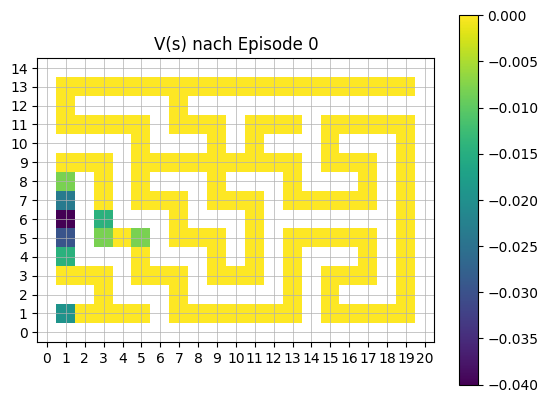

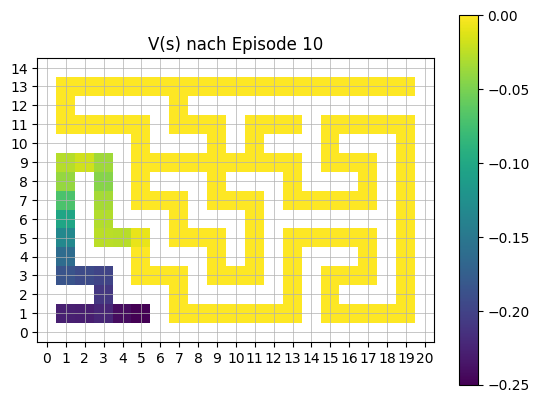

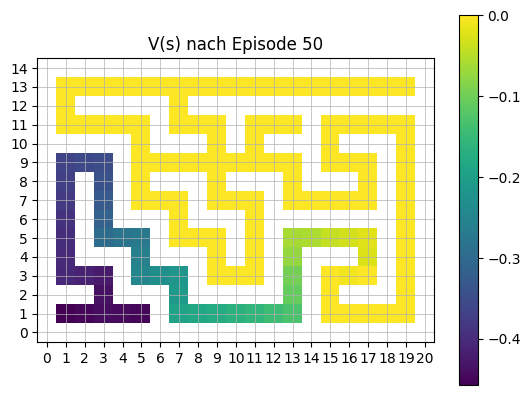

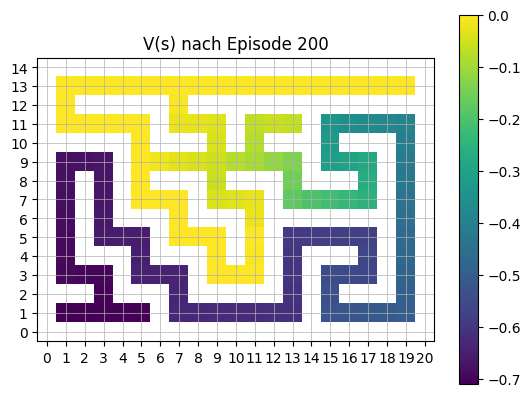

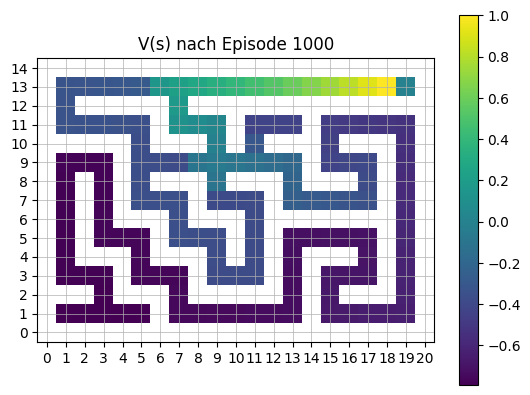

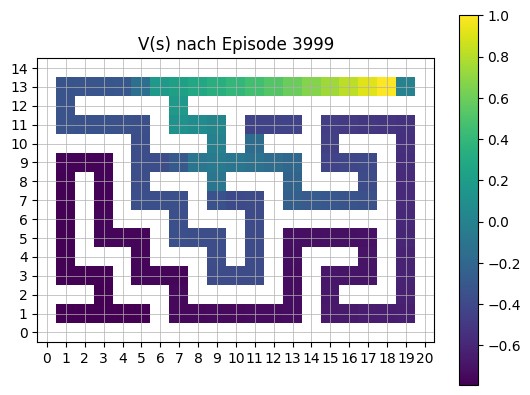

In [5]:
# -----------------------------
# 3) Q-Learning 
# -----------------------------
n_states = H * W # Anzahl der möglichen Positionene im Netz 
n_actions = len(ACTIONS) # Anzahl der möglichen Aktionen

Q = np.zeros((n_states, n_actions), dtype=np.float64) # Definiert leere Q-Value Tabelle, die nach und nach durch Lernen gefüllt wird. Am Anfang ist die Tabelle leer.

alpha = 0.2     # Lernrate
gamma = 0.95    # Discount
epsilon = 1.0   # Start exploration (Am Anfang zufällig, daher $\varepsilon = 1$)
eps_min = 0.05  # minimale Decay-Rate
eps_decay = 0.995 # epsilon_neu = eps_decay*epsilon

episodes = 4000
max_steps = 200

snapshots = []  # Snapshots einfügen, um das Lernen darzustellen
snapshot_episodes = [0, 10, 50, 200, 1000, 3999] # Frames für Snapshops auswählen

rng = np.random.default_rng(0) # erstellt ein Objekt, mit dem du Zufallszahlen erzeugen kannst
returns = []

for ep in range(episodes):
    s = start
    total = 0.0

    for t in range(max_steps):
        si = state_to_idx(s)

        # ε-greedy
        if rng.random() < epsilon:
            a = rng.integers(n_actions)
        else:
            a = int(np.argmax(Q[si]))

        s2, r, done = step(s, a)
        s2i = state_to_idx(s2)

        # Update the Q-Function
        td_target = r + gamma * np.max(Q[s2i])
        Q[si, a] += alpha * (td_target - Q[si, a])

        s = s2
        total += r

        if done:
            break

    if ep in snapshot_episodes:
        V_snapshot = np.max(Q, axis=1).reshape(H, W) # State-Value-Funktion np.max(Q, axis=1)
        snapshots.append((ep, V_snapshot.copy())) 

    epsilon = max(eps_min, epsilon * eps_decay)
    returns.append(total)

for ep, V in snapshots:
    plt.figure()
    plt.title(f"V(s) nach Episode {ep}")
    
    V_plot = V.copy()
    V_plot[maze == 1] = np.nan  # Wände ausblenden
    
    plt.imshow(V_plot, interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(W))
    plt.yticks(range(H))
    plt.grid(True, linewidth=0.5)
    plt.gca().invert_yaxis()
    
    plt.show()

## Policy aus Q ableiten

zeilenweise das Maximum suchen, d.h. für jeden Zustand wird die Aktion mit dem höchsten Q-Wert gewählt.

In [11]:
# -----------------------------
# 4) Policy aus Q ableiten
# -----------------------------

for line in Q:
    print(line)
policy = np.argmax(Q, axis=1) # Policy np.argmax(Q, axis=1)
print(policy)

[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[-0.9481918  -0.78757026 -0.94819172 -0.94819164]
[-0.94756718 -0.78691606 -0.94757022 -0.7881923 ]
[-0.94691594 -0.78758419 -0.78622743 -0.78757105]
[-0.93957474 -0.79183257 -0.93414935 -0.78691752]
[-0.90935795 -0.89950406 -0.91854351 -0.79186322]
[0. 0. 0. 0.]
[-0.9151932  -0.75283189 -0.75743121 -0.91519038]
[-0.91283269 -0.75034936 -0.91283183 -0.75519066]
[-0.91035009 -0.74773617 -0.91034974 -0.75283385]
[-0.9077365  -0.74498544 -0.90773703 -0.75035228]
[-0.90498543 -0.74208993 -0.90498679 -0.74773669]
[-0.90209557 -0.73904204 -0.90209024 -0.74500994]
[-0.89904317 -0.89904235 -0.73583372 -0.74210293]
[0. 0. 0. 0.]
[-0.83500452 -0.66842409 -0.68125619 -0.83500425]
[-0.82842818 -

## Gelernten Pfad ausführen

Nach dem Training durchläuft der Agent den Pfad mit der gelernten Policy durch das Labyrinth. 
Für die spätere Darstellung wird der Pfad gespeichert.

In [7]:
# -----------------------------
# 5) Pfad ausführen 
# -----------------------------
path = [start]
s = start
for _ in range(300):
    si = state_to_idx(s)
    a = int(policy[si])
    s2, _, done = step(s, a) # Reward wird hier nicht benötigt

    # falls er festhängt: abbrechen
    if s2 == s:
        break

    path.append(s2)
    s = s2
    if done:
        break

## Visualisierung

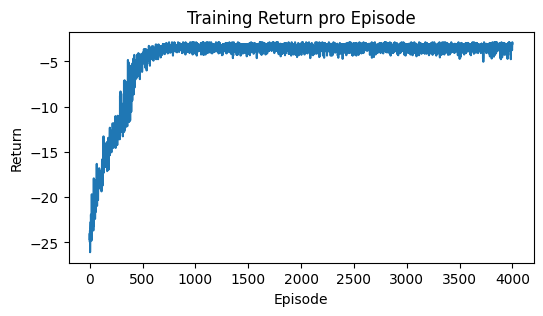

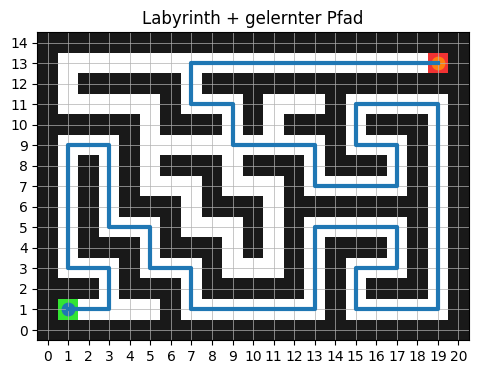

Pfadlänge: 99 Ende: (np.int32(13), np.int32(19)) Goal: (13, 19)


In [8]:
def draw_maze_with_path(path=None):
    img = np.ones((H, W, 3), dtype=np.float32)

    # Wände schwarz
    img[maze == 1] = [0.1, 0.1, 0.1]

    # Start grün, Ziel rot
    sr, sc = start
    gr, gc = goal
    img[sr, sc] = [0.2, 0.9, 0.2]
    img[gr, gc] = [0.95, 0.2, 0.2]

    plt.figure(figsize=(6, 4))
    plt.imshow(img, interpolation="nearest")
    plt.xticks(range(W))
    plt.yticks(range(H))
    plt.grid(True, linewidth=0.5)

    if path is not None and len(path) > 1:
        ys = [p[0] for p in path]
        xs = [p[1] for p in path]
        plt.plot(xs, ys, linewidth=3)  # default Farbe
        plt.scatter([xs[0]], [ys[0]], s=80)
        plt.scatter([xs[-1]], [ys[-1]], s=80)

    plt.title("Labyrinth + gelernter Pfad")
    plt.gca().invert_yaxis()  # optional: (0,0) oben links wie array
    plt.show()

def draw_training_curve(returns):
    plt.figure(figsize=(6, 3))
    plt.plot(returns)
    plt.title("Training Return pro Episode")
    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.show()

draw_training_curve(returns)
draw_maze_with_path(path)
print("Pfadlänge:", len(path), "Ende:", path[-1], "Goal:", goal)

### Aufgabe 1:

Erzeuge ein größeres Labyrinth und versuche es, möglichst kompliziert zu machen.

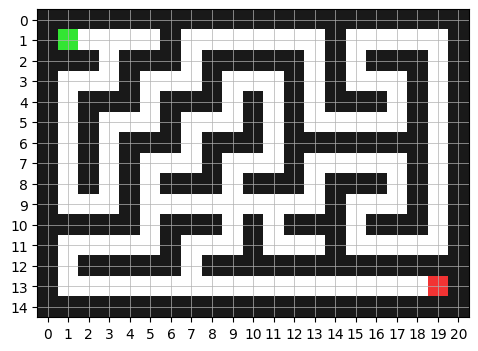

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Labyrinth 
# -----------------------------

# Labyrinth zeichen
maze_str = [
    "#####################",
    "#S....#.......#.....#",
    "###.###.#####.#.###.#",
    "#...#...#...#.#...#.#",
    "#.###.###.#.#.###.#.#",
    "#.#...#...#.#.....#.#",
    "#.#.###.###.#######.#",
    "#.#.#...#...#.....#.#",
    "#.#.#.###.###.###.#.#",
    "#...#.........#...#.#",
    "#####.###.#.###.###.#",
    "#.....#...#...#.....#",
    "#.#####.#############",
    "#..................G#",
    "#####################",
]

H = len(maze_str)
W = len(maze_str[0])

# Numpy array erstellen und der Zeichnung entsprechend füllen
maze = np.zeros((H, W), dtype=np.int32)
start = None
goal = None

for r in range(H):
    for c in range(W):
        ch = maze_str[r][c]
        if ch == "#":
            maze[r, c] = 1
        elif ch == "S":
            start = (r, c)
        elif ch == "G":
            goal = (r, c)

# prüfen, dass Start und Ziel nur einfach vorhanden sind.
assert start is not None and goal is not None

img = np.ones((H, W, 3), dtype=np.float32)

# Wände schwarz
img[maze == 1] = [0.1, 0.1, 0.1]

# Start grün, Ziel rot
sr, sc = start
gr, gc = goal
img[sr, sc] = [0.2, 0.9, 0.2]
img[gr, gc] = [0.95, 0.2, 0.2]

plt.figure(figsize=(6, 4))
plt.imshow(img, interpolation="nearest")
plt.xticks(range(W))
plt.yticks(range(H))
plt.grid(True, linewidth=0.5)




Pfadlänge: 99 Ende: (np.int32(13), np.int32(19)) Goal: (13, 19)


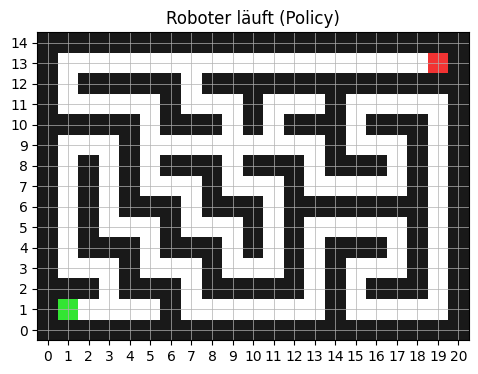

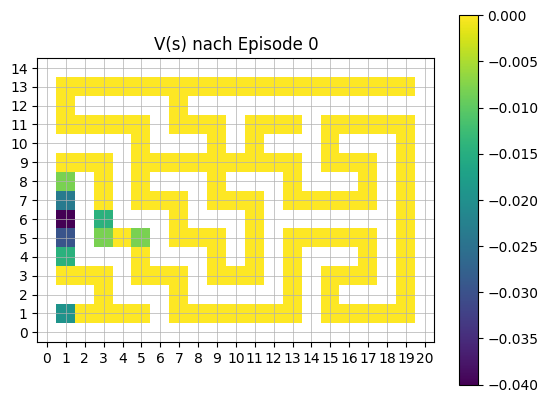

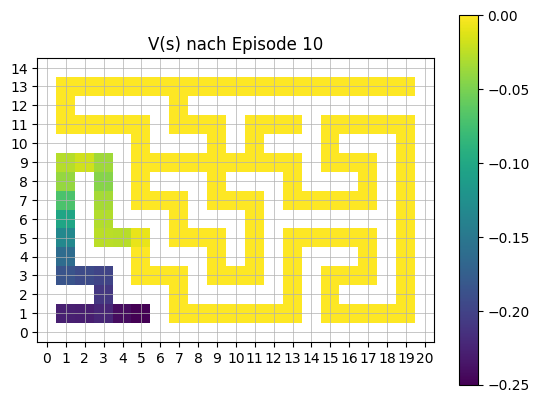

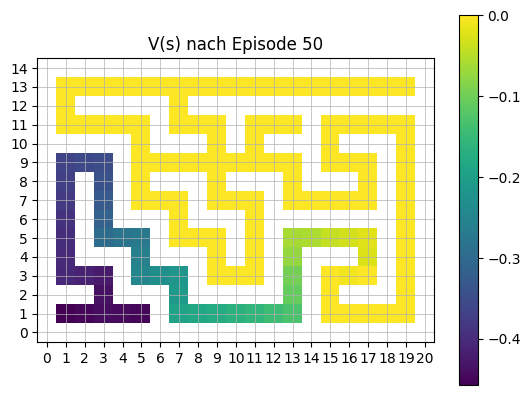

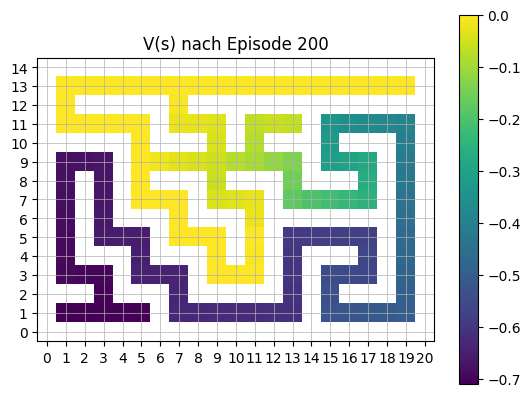

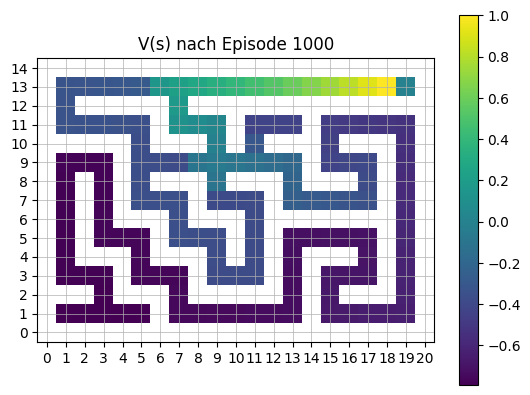

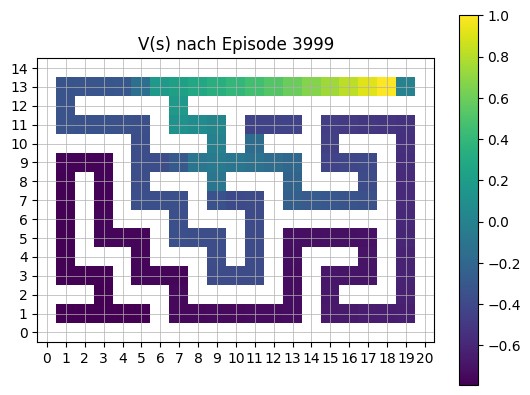

Speichere GIF...
Fertig! Datei gespeichert als robot_maze.gif


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ============================================================
# 1) LABYRINTH DEFINIEREN (Grid-World Environment)
# ============================================================
# Jede Zelle ist:
#   "." = frei
#   "#" = Wand
#   "S" = Startzustand
#   "G" = Zielzustand

# Labyrinth zeichen
maze_str = [
    "#####################",
    "#S....#.......#.....#",
    "###.###.#####.#.###.#",
    "#...#...#...#.#...#.#",
    "#.###.###.#.#.###.#.#",
    "#.#...#...#.#.....#.#",
    "#.#.###.###.#######.#",
    "#.#.#...#...#.....#.#",
    "#.#.#.###.###.###.#.#",
    "#...#.........#...#.#",
    "#####.###.#.###.###.#",
    "#.....#...#...#.....#",
    "#.#####.#############",
    "#..................G#",
    "#####################",
]

H = len(maze_str)      # Höhe
W = len(maze_str[0])   # Breite

# Maze als numerisches Grid:
# 0 = frei
# 1 = Wand
maze = np.zeros((H, W), dtype=np.int32)

start = None
goal = None

for r in range(H):
    for c in range(W):
        ch = maze_str[r][c]
        if ch == "#":
            maze[r, c] = 1
        elif ch == "S":
            start = (r, c)
        elif ch == "G":
            goal = (r, c)

assert start is not None and goal is not None


# ============================================================
# 2) ACTION SPACE DEFINIEREN
# ============================================================
# Aktionen werden als Bewegungsvektoren definiert:
# 0 = hoch, 1 = rechts, 2 = runter, 3 = links
ACTIONS = np.array([
    (-1, 0),  # hoch
    (0, 1),   # rechts
    (1, 0),   # runter
    (0, -1),  # links
], dtype=np.int32)


def state_to_idx(s):
    """
    Wandelt 2D-Position (r,c) in einen eindimensionalen
    Zustandsindex um (für Q-Tabelle).
    """
    return s[0] * W + s[1]


def step(state, action):
    """
    Environment-Dynamik:
    Gegeben aktueller Zustand + Aktion ->
    liefert neuen Zustand, Reward, Done-Flag.
    """

    r, c = state
    dr, dc = ACTIONS[action]
    nr, nc = r + dr, c + dc

    # Kleine negative Schrittstrafe
    # -> fördert kürzere Wege
    reward = -0.04
    done = False

    # Wenn Wand oder außerhalb:
    # Agent bleibt stehen + stärkere Strafe
    if not (0 <= nr < H and 0 <= nc < W) or maze[nr, nc] == 1:
        nr, nc = r, c
        reward = -0.2

    # Wenn Ziel erreicht:
    if (nr, nc) == goal:
        reward = 1.0
        done = True

    return (nr, nc), reward, done


# ============================================================
# 3) Q-LEARNING (Tabellarisch mit NumPy)
# ============================================================
# Q(s,a) speichert Erwartungswert für Zustand s und Aktion a

n_states = H * W
n_actions = len(ACTIONS)

Q = np.zeros((n_states, n_actions), dtype=np.float64)

# Lernparameter
alpha = 0.2      # Lernrate
gamma = 0.95     # Discount-Faktor (Zukunftsgewichtung)
epsilon = 1.0    # Anfangs-Exploration
eps_min = 0.05
eps_decay = 0.995

episodes = 4000
max_steps = 200

rng = np.random.default_rng(0)

snapshots = []
snapshot_episodes = [0, 10, 50, 200, 1000, 3999]

# -------------------------
# Trainingsloop
# -------------------------
for ep in range(episodes):

    s = start

    for _ in range(max_steps):

        si = state_to_idx(s)

        # ε-greedy Policy:
        # Mit Wahrscheinlichkeit ε -> zufällige Aktion
        # sonst beste bekannte Aktion
        if rng.random() < epsilon:
            a = int(rng.integers(n_actions))
        else:
            a = int(np.argmax(Q[si]))

        s2, r, done = step(s, a)
        s2i = state_to_idx(s2)

        # Q-Learning Update:
        #
        # Q(s,a) ← Q(s,a) + α [ r + γ max_a' Q(s',a') - Q(s,a) ]
        #
        td_target = r + gamma * np.max(Q[s2i])
        Q[si, a] += alpha * (td_target - Q[si, a])

        s = s2

        if done:
            break

    if ep in snapshot_episodes:
        V_snapshot = np.max(Q, axis=1).reshape(H, W)
        snapshots.append((ep, V_snapshot.copy())) 

    # Exploration langsam reduzieren
    epsilon = max(eps_min, epsilon * eps_decay)


# ============================================================
# 4) POLICY AUS Q-TABELLE ABLEITEN
# ============================================================
# Beste Aktion pro Zustand
policy = np.argmax(Q, axis=1)


# ============================================================
# 5) GREEDY PFAD EXTRAHIEREN (ohne Exploration)
# ============================================================
path = [start]
s = start

for _ in range(500):
    si = state_to_idx(s)
    a = int(policy[si])

    s2, _, done = step(s, a)

    # Falls er sich nicht bewegt -> abbrechen
    if s2 == s:
        break

    path.append(s2)
    s = s2

    if done:
        break

print("Pfadlänge:", len(path), "Ende:", path[-1], "Goal:", goal)


# ============================================================
# 6) VISUALISIERUNG DES LABYRINTHS
# ============================================================

# RGB-Image erzeugen
img = np.ones((H, W, 3), dtype=np.float32)

# Wände dunkel
img[maze == 1] = [0.1, 0.1, 0.1]

# Start grün, Ziel rot
sr, sc = start
gr, gc = goal
img[sr, sc] = [0.2, 0.9, 0.2]
img[gr, gc] = [0.95, 0.2, 0.2]

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(img, interpolation="nearest")

ax.set_xticks(range(W))
ax.set_yticks(range(H))
ax.grid(True, linewidth=0.5)
ax.set_title("Roboter läuft (Policy)")
ax.invert_yaxis()  # Koordinatensystem an Array anpassen


# ============================================================
# 7) ANIMATION DES ROBOTERS
# ============================================================

# Punkt = Roboter
robot_dot, = ax.plot([], [], marker="o", markersize=14, linestyle="")

# Linie = bisheriger Weg
trail_line, = ax.plot([], [], linewidth=3)

# Textanzeige
step_text = ax.text(0.02, 0.98, "", transform=ax.transAxes, va="top")


def init():
    """
    Initialisiert leere Animation.
    """
    robot_dot.set_data([], [])
    trail_line.set_data([], [])
    step_text.set_text("")
    return robot_dot, trail_line, step_text


def update(frame):
    """
    Wird für jedes Frame aufgerufen.
    Setzt Roboterposition und Trail.
    """
    r, c = path[frame]

    # Roboterposition (Achtung: x=c, y=r)
    robot_dot.set_data([c], [r])

    # Spur bis aktuelles Frame
    xs = [p[1] for p in path[:frame+1]]
    ys = [p[0] for p in path[:frame+1]]
    trail_line.set_data(xs, ys)

    step_text.set_text(f"Schritt: {frame}/{len(path)-1}")

    return robot_dot, trail_line, step_text


anim = FuncAnimation(
    fig,
    update,
    frames=len(path),
    init_func=init,
    interval=250,   # Millisekunden pro Frame
    blit=True,
    repeat=False
)


for ep, V in snapshots:
    plt.figure()
    plt.title(f"V(s) nach Episode {ep}")
    
    V_plot = V.copy()
    V_plot[maze == 1] = np.nan  # Wände ausblenden
    
    plt.imshow(V_plot, interpolation="nearest")
    plt.colorbar()
    plt.xticks(range(W))
    plt.yticks(range(H))
    plt.grid(True, linewidth=0.5)
    plt.gca().invert_yaxis()
    
    plt.show()
    
# ============================================================
# 8) GIF EXPORT
# ============================================================

print("Speichere GIF...")

anim.save(
    "robot_maze.gif",
    writer="pillow",
    fps=4  # Frames pro Sekunde im GIF
)

print("Fertig! Datei gespeichert als robot_maze.gif")

plt.show()

# Abschlussprojekt

 <figure style="text-align: center;">
    <img src="Bilder/RL-Roboter.png" alt="Roboter" width = 300>
    <figcaption>Roboter mit US-Sensor und Kamera</figcaption>
  </figure>